# Polar plot
Based on https://github.com/climberlenny/test_openberg/blob/main/toolbox/postprocessing.py

In [1]:
cd ~/work/tutorials/sources/OpenDrift/openberg_custom_juliette 

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette


In [2]:
from src.utils import *
from src.utils2 import *
import glob

In [3]:
# Read and subset tracker data
obs = read_tracker('./input/Osker-X2.csv')['full']

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette/src/utils2.py:109: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [60]:
# Read simulation data
note = 'current_wind_nextsim'
# --- Which simulation data for plot? ---
file_contain_all = ['wind']
file_contain_any = ['topaz','glophyanfc','nextsim',]
file_notcontain = ['topaz4','glorys','slope','wa','ens']
file_l = glob.glob("./results/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l

['./results/juliette_glophyanfc_windglophynrt.nc',
 './results/juliette_topaz5_windglophynrt.nc',
 './results/juliette_nextsimanfc_glophyanfc_windglophynrt.nc',
 './results/juliette_nextsimanfc_topaz5_windglophynrt.nc',
 './results/juliette_topaz6_topaz5_windglophynrt.nc',
 './results/juliette_nextsimanfc_topaz6_topaz5_windglophynrt.nc']

In [61]:
# --- Open all simulation results in one dataset ---
with xr.open_mfdataset(
    file_l,
    combine="nested",
    concat_dim="run",
    parallel=True,
    engine="netcdf4",
    # chunks={'time': 10}
) as simall: 
    simall = simall.assign_coords(run=file_l)  # or any list of labels

In [62]:
# --- Processing before plotting ---
# Create obs-sim pairs by a) looking for the cloosest observation time for every simulation time,
# b) subset (both datasets) to 6hourly or daily frequnecy, then as a),
# or c) looking for closest sim in obs.time.
sim = simall
# a)Selects the nearest times in obs for every sim.time whihc is hourly
obs_simfreq = obs.sel(time=sim.time, method="nearest") 
# b)
sim_daily = sim.resample(time="1D").first() #.mean() 
sim_6h = sim.sel(time=sim.time.dt.hour.isin([0, 6, 12, 18]))
sim_6h.time
obs_dailysimfreq = obs.sel(time=sim_daily.time, method="nearest") 
# c)
sim_obstime = sim.sel(time=obs.time, method="nearest") 
sim_obstime.time

#or daily averages?
#Cut off from 5 Dec on as no sim results!

sim_sub = sim_obstime

/tmp/ipykernel_51423/1628591972.py:27: RuntimeWarning: divide by zero encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0
/tmp/ipykernel_51423/1628591972.py:27: RuntimeWarning: invalid value encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0


1.5321425931128445 8.787779911710693 1959.2718540754036


/tmp/ipykernel_51423/1628591972.py:98: RuntimeWarning: divide by zero encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0
/tmp/ipykernel_51423/1628591972.py:121: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(
/tmp/ipykernel_51423/1628591972.py:98: RuntimeWarning: invalid value encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0


1.1969018801864697 21.369101239143042 1457.2668447489395
2.814695569821542 3.431656463284851 1959.2718540754036
0.9748934400410147 19.53403455436892 1457.2668447489395
1.0498343210809231 2.9094208517634517 1959.2718540754036
3.1774938483228494 4.474083205570447 1735.4829643262797
1.3593762698400353 4.2540445070235835 1735.4829643262797


/tmp/ipykernel_51423/1628591972.py:182: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  Patch(facecolor=plt.cm.get_cmap('viridis')(0.2), edgecolor='k',label='Confidence contours (all input)'),


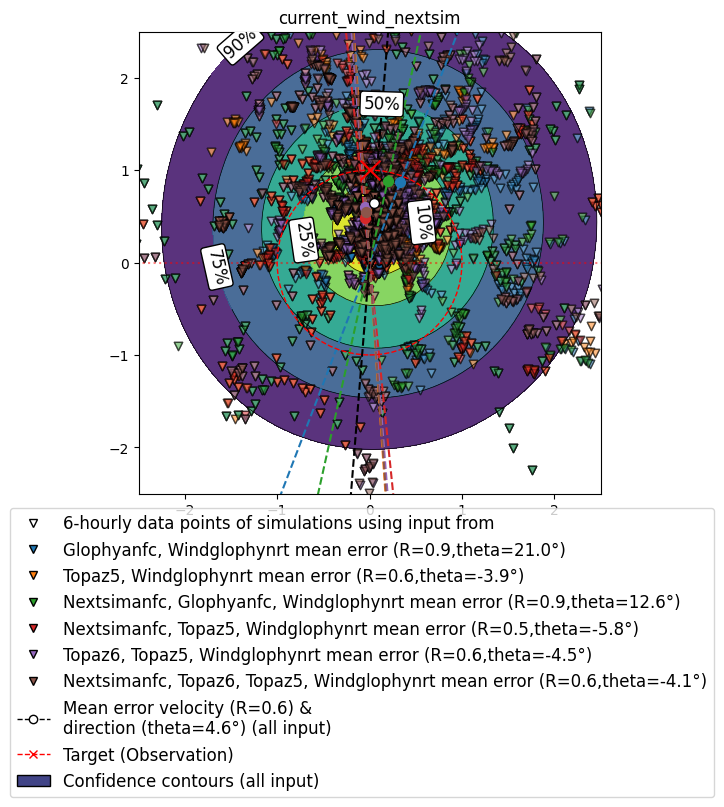

In [63]:
import pyproj
from scipy.stats import circmean
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
geod = pyproj.Geod(ellps="WGS84")

cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
col = cmap(np.linspace(0, 1, 20))[::2]#20 colors

means_save = {}

# observation = ref
azimuth_alpha, a2, distance0 = geod.inv(
    obs.lon[:-1],obs.lat[:-1],obs.lon[1:],obs.lat[1:])
dt = np.diff(obs.time) / np.timedelta64(1, "s")  #individual timesteps between the points
vel0 = distance0 / dt #distance/seconds
vel0

# simulation results of all together -> density
azimuth_betha, a2, distance1 = geod.inv(
    sim_sub.lon[:,:,:-1],sim_sub.lat[:,:,:-1],sim_sub.lon[:,:,1:],sim_sub.lat[:,:,1:])
dt = np.diff(sim_sub.time) / np.timedelta64(1, "s") #individual timesteps between the points
vel1 = distance1 / dt #distance/seconds

# calculate the coordinates in the polar plot
THETA = np.array((azimuth_betha - azimuth_alpha + 360) % 360)
R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0

#average meassures:
r_avg_with_outsiders = np.nanmean(R)
theta_avg_with_outsiders = circmean(THETA[~np.isnan(THETA)])
print(theta_avg_with_outsiders, r_avg_with_outsiders, np.nanmax(R))

#calc insiders and gridded densities:
outsiders = (R > 3).sum() / len(R) * 100
# Convert polar coordinates to Cartesian coordinates
x, y = polar_to_cartesian(np.pi / 2 - np.radians(THETA[R <= 3]), R[R <= 3])
x_outsiders, y_outsiders = polar_to_cartesian(
    np.pi / 2 - np.radians(theta_avg_with_outsiders), r_avg_with_outsiders)
r_avg_insiders_all = np.mean(R[R <= 3])
theta_avg_insiders_all = circmean(THETA[R <= 3], high=360, low=0)
x_insiders_all, y_insiders_all = polar_to_cartesian(
    np.pi / 2 - np.radians(theta_avg_insiders_all), r_avg_insiders_all)

grid_size = 100
percentages = [0.9, 0.75, 0.5, 0.25, 0.1, 0]
points_insiders = np.vstack((x, y)).T
X, Y, density_grid = create_density_grid(points_insiders, grid_size, c=0.5)
levels = find_contour_levels(density_grid, percentages)

fig, ax = plt.subplots(figsize=(6, 6))
contourf = ax.contourf(
    X,
    Y,
    density_grid,
    levels=levels,
    cmap="viridis",
    alpha=0.9,
)
contour = ax.contour(
    X,
    Y,
    density_grid,
    levels=levels,
    colors="k",
    linewidths=(0.5,),
)
clabels = ax.clabel(
    contour,
    inline=True,
    fontsize=12,
    fmt={level: f"{int(p*100)}%" for level, p in zip(levels, percentages)},
)
## Customize clabels
for txt in clabels:
    txt.set_bbox(
        dict(facecolor="white", edgecolor=txt.get_color(), boxstyle="round,pad=0.2")
    )
    txt.set_color("black")

ax.scatter(
    x, y, alpha=0.5, marker="v", color='w', edgecolor="k", label="6-hourly Data points \nof simulations using input from"
)


#simulation reuslts per run seperately
for runn,run in enumerate(sim_sub.run):
    sub_run = sim_sub.sel(run=run)
    col_run = col[runn]
    # simulation
    azimuth_betha, a2, distance1 = geod.inv(
        sub_run.lon[:,:-1],sub_run.lat[:,:-1],sub_run.lon[:,1:],sub_run.lat[:,1:])
    dt = np.diff(sub_run.time) / np.timedelta64(1, "s") #individual timesteps between the points
    vel1 = distance1 / dt #distance/seconds
    
    # calculate the coordinates in the polar plot
    THETA = np.array((azimuth_betha - azimuth_alpha + 360) % 360)
    R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0
    
    #average meassures:
    r_avg_with_outsiders = np.nanmean(R)
    theta_avg_with_outsiders = circmean(THETA[~np.isnan(THETA)])
    print(theta_avg_with_outsiders, r_avg_with_outsiders, np.nanmax(R))
    
    #calc insiders and gridded densities:
    outsiders = (R > 3).sum() / len(R) * 100
    # Convert polar coordinates to Cartesian coordinates
    x, y = polar_to_cartesian(np.pi / 2 - np.radians(THETA[R <= 3]), R[R <= 3])
    x_outsiders, y_outsiders = polar_to_cartesian(
        np.pi / 2 - np.radians(theta_avg_with_outsiders), r_avg_with_outsiders)
    r_avg_insiders = np.mean(R[R <= 3])
    theta_avg_insiders = circmean(THETA[R <= 3], high=360, low=0)
    x_insiders, y_insiders = polar_to_cartesian(
        np.pi / 2 - np.radians(theta_avg_insiders), r_avg_insiders)
    means_save[run.item()] = [r_avg_insiders,theta_avg_insiders]

    ax.scatter(
        x, y, alpha=0.5, marker="v", color=col_run, edgecolor="k", 
        label=f"{run.item()[19:-3]} \nmean (R={np.round(r_avg_insiders,1)},theta={np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°)"
    )
    ax.scatter(
        x_insiders,
        y_insiders,
        marker="o",
        s=50,
        c=col_run,
        # label=f"Mean (R={np.round(r_avg_insiders,1)},theta={np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°)",
        zorder=30,
    )

    ax.plot(
        np.linspace(-3, 3, 100),
        np.tan(np.pi / 2 - np.deg2rad(theta_avg_insiders)) * np.linspace(-3, 3, 100),
        color=col_run,
        linestyle="--",
        # label=f"average deviation : {np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°",
    )

#all simulations again
ax.scatter(
    x_insiders_all,
    y_insiders_all,
    marker="o",
    s=50,
    facecolor='w',edgecolor='k',
    # label=f"mean without ouliers (R={np.round(r_avg_insiders,1)},theta={np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°)",
    label=f"Mean error velocity (R={np.round(r_avg_insiders_all,1)})",
    zorder=30,
)

ax.plot(
    np.linspace(-3, 3, 100),
    np.tan(np.pi / 2 - np.deg2rad(theta_avg_insiders_all)) * np.linspace(-3, 3, 100),
    color="k",
    linestyle="--",
    label=f"Mean error direction (theta={np.round(theta_avg_insiders_all,1) if theta_avg_insiders_all<180 else np.round(theta_avg_insiders_all-360,1)}°)" #f"average deviation : {np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°",
)
    
#other plots things
ax.scatter(0, 1, marker="x", s=200, c="r", label="Target", zorder=20)
ax.hlines(0, xmin=-5, xmax=5, linestyle=":", color="r", alpha=0.5)
ax.set_xlim([-2.5, 2.5])
ax.set_ylim([-2.5, 2.5])
circle1 = plt.Circle(
    (0, 0), 1, edgecolor="r", linestyle="--", fc=None, fill=False, zorder=30
)
ax.add_patch(circle1)
plt.gca().set_aspect(
    "equal", adjustable="box"
)  # Set aspect ratio to make it look polar
ax.set_title(note)
#legend
# fig.legend(fontsize=12)
legend_elements = [Line2D([0], [0],linestyle='-', color='w', marker='v', markerfacecolor='w',markeredgecolor='k', lw=1,
                          label=f"6-hourly data points of simulations using input from "),]
legend_elements = legend_elements+[Line2D([0], [0],linestyle='-', color='w', marker='v', markerfacecolor=col[runn],markeredgecolor='k', lw=1,
                          label=f"{run.item()[19:-3].replace('_',', ').title()} mean error (R={np.round(means_save[run.item()][0],1)},theta={np.round(means_save[run.item()][1],1) if means_save[run.item()][1]<180 else np.round(means_save[run.item()][1]-360,1)}°)") for runn,run in enumerate(sim_sub.run)]
legend_elements = legend_elements+[                      
                  Line2D([0], [0],linestyle='--', color='k',marker='o',markerfacecolor='w',markeredgecolor='k', lw=1,
                         label=f"Mean error velocity (R={np.round(r_avg_insiders_all,1)}) & \ndirection (theta={np.round(theta_avg_insiders_all,1) if theta_avg_insiders_all<180 else np.round(theta_avg_insiders_all-360,1)}°) (all input)"),
                  Line2D([0], [0],linestyle='--', color='r',marker='x', lw=1,label='Target (Observation)'),
                  Patch(facecolor=plt.cm.get_cmap('viridis')(0.2), edgecolor='k',label='Confidence contours (all input)'),
                  ]
leg = fig.legend(handles=legend_elements,fontsize=12,#,ncol=len(legend_elements0+legend_elements2),                  columnspacing=0.6,labelspacing=0.3,loc='center',bbox_to_anchor=bbox_dict[kw][0])
                   loc='upper center', bbox_to_anchor=(0.5,0.1))
                   # loc='center left', bbox_to_anchor=(0.9,0.5))

if note!=False: plt.savefig('./results/analysis_polarplot_%s.png'%(note), bbox_inches="tight", dpi=400)
plt.show()

In [54]:
from scipy.spatial.distance import pdist

def polar_to_cartesian(theta, r):
    """Convert polar coordinates to Cartesian coordinates."""
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

def create_density_grid(points, grid_size=100, c=0.5):
    points = points[~np.isnan(points).any(axis=1)]
    # Calculer la distance moyenne entre les points
    d_avg = calculate_average_distance(points) + 1
    # Déterminer sigma en fonction de d_avg et du paramètre c
    sigma = c * d_avg

    # Déterminer les limites de la grille
    x_min, x_max = min(points[:, 0]) - 2 * sigma, max(points[:, 0]) + 2 * sigma
    y_min, y_max = min(points[:, 1]) - 2 * sigma, max(points[:, 1]) + 2 * sigma

    # Créer une grille de coordonnées
    x = np.linspace(x_min, x_max, grid_size)
    y = np.linspace(y_min, y_max, grid_size)
    X, Y = np.meshgrid(x, y)

    # Initialiser la grille de densité
    density_grid = np.zeros((grid_size, grid_size))

    # Nombre de points
    N = len(points)

    # Appliquer la distribution gaussienne à chaque point
    for point in points:
        dx = X - point[0]
        dy = Y - point[1]
        r = np.sqrt(dx**2 + dy**2)
        density_grid += gaussian_kernel(r, sigma) / N

    return X, Y, density_grid

def calculate_average_distance(points):
    if len(points) > 1000:
        distances = pdist(points[::50])
    else:
        distances = pdist(points)
    d_avg = np.mean(distances)
    return d_avg
    
def gaussian_kernel(r, sigma):
    return np.exp(-(r**2) / (2 * sigma**2)) / (2 * np.pi * sigma**2)

def find_contour_levels(density_grid, percentages):
    sorted_density = np.sort(density_grid.ravel())[::-1]
    cumsum_density = np.cumsum(sorted_density)
    total_density = cumsum_density[-1]
    levels = [
        sorted_density[np.searchsorted(cumsum_density, p * total_density)]
        for p in percentages
    ]
    levels.sort()  # S'assurer que les niveaux sont dans l'ordre croissant
    return levels



In [ ]:
# plt.plot(range(obs.time.size), obs.time)
# plt.plot(range(sim_obstime.time.size),sim_obstime.time)